In [7]:
# Final Project: Quantitative Time-Series Analysis & Modeling
## Sector ETF Analysis: XLK, XLE, and XLF
### Author: Andrew Rush

In [8]:
## Introduction

##This project analyzes three sector ETFs: XLK (Technology), XLE (Energy), and XLF (Financials).
## The goal is to clean and preprocess historical time-series data, explore return behavior and volatility patterns, and apply a forecasting model to evaluate predictive performance.

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [10]:
## Data Collection

## Historical daily ETF data was downloaded from Yahoo Finance using the yfinance Python package. The sample begins on January 1, 2019.

In [11]:
tickers = ['XLK', 'XLE', 'XLF']
data = yf.download(tickers, start='2019-01-01')
data.head()

/tmp/ipykernel_1939/2995963768.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2019-01-01')
[*********************100%***********************]  3 of 3 completed


Price           Close                             High                        \
Ticker            XLE        XLF        XLK        XLE        XLF        XLK   
Date                                                                           
2019-01-02  21.123751  20.933628  29.032204  21.264624  20.977203  29.205404   
2019-01-03  20.914246  20.463011  27.567013  21.261010  20.829044  28.311308   
2019-01-04  21.625834  21.142784  28.788782  21.690852  21.186359  28.910490   
2019-01-07  21.947315  21.168934  29.046247  22.106250  21.360665  29.242855   
2019-01-08  22.117085  21.186357  29.289663  22.304916  21.395519  29.430096   

Price             Low                             Open                        \
Ticker            XLE        XLF        XLK        XLE        XLF        XLK   
Date                                                                           
2019-01-02  20.282125  20.393292  28.381531  20.386875  20.454298  28.418978   
2019-01-03  20.675845  20.410721  27.529565  21.185156  20.776754  28.292583   
2019-01-04  21.152645  20.759320  27.983632  21.275458  20.811610  28.072574   
2019-01-07  21.499412  20.968486  28.723252  21.788382  21.099212  28.788787   
2019-01-08  21.997885  20.942336  28.943263  22.254346  21.360660  29.327113   

Price         Volume                      
Ticker           XLE       XLF       XLK  
Date                                      
2019-01-02  49785200  62945000  30885800  
2019-01-03  36048200  65729700  49893400  
2019-01-04  42703000  64638400  41535600  
2019-01-07  36113400  48167000  23817200  
2019-01-08  37384600  90114700  26005200

In [12]:
## Data Cleaning and Preprocessing

## Closing prices were extracted, sorted by date, checked for missing values, and daily percentage returns were calculated.

In [13]:
prices = data['Close'].copy()
prices = prices.sort_index()
prices = prices.dropna()

returns = prices.pct_change().dropna()

print(prices.head())
print(returns.head())

Ticker            XLE        XLF        XLK
Date                                       
2019-01-02  21.123751  20.933628  29.032204
2019-01-03  20.914246  20.463011  27.567013
2019-01-04  21.625834  21.142784  28.788782
2019-01-07  21.947315  21.168934  29.046247
2019-01-08  22.117085  21.186357  29.289663
Ticker           XLE       XLF       XLK
Date                                    
2019-01-03 -0.009918 -0.022481 -0.050468
2019-01-04  0.034024  0.033220  0.044320
2019-01-07  0.014866  0.001237  0.008943
2019-01-08  0.007735  0.000823  0.008380
2019-01-09  0.015842  0.004936  0.012946


In [14]:
## Exploratory Data Analysis

## The first visualization compares the growth of a hypothetical $100 investment across all three ETFs.

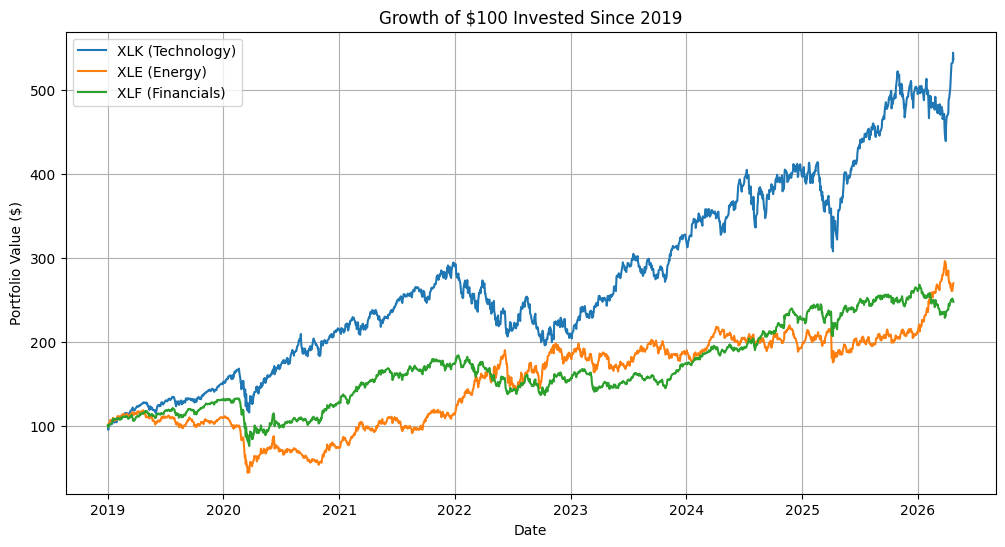

In [15]:
normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(12,6))
plt.plot(normalized.index, normalized['XLK'], label='XLK (Technology)')
plt.plot(normalized.index, normalized['XLE'], label='XLE (Energy)')
plt.plot(normalized.index, normalized['XLF'], label='XLF (Financials)')

plt.title('Growth of $100 Invested Since 2019')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
## Technology significantly outperformed the other sectors over the sample period, while Energy showed more cyclical behavior.

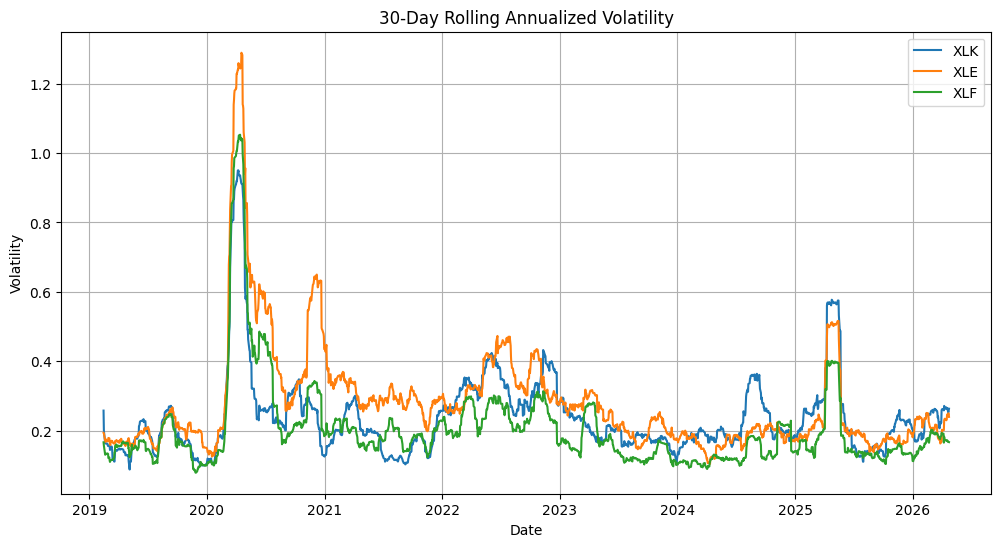

In [17]:
rolling_vol = returns.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(12,6))
plt.plot(rolling_vol.index, rolling_vol['XLK'], label='XLK')
plt.plot(rolling_vol.index, rolling_vol['XLE'], label='XLE')
plt.plot(rolling_vol.index, rolling_vol['XLF'], label='XLF')

plt.title('30-Day Rolling Annualized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
## Rolling volatility highlights periods of market stress, especially during the 2020 COVID shock and later inflation-driven volatility.

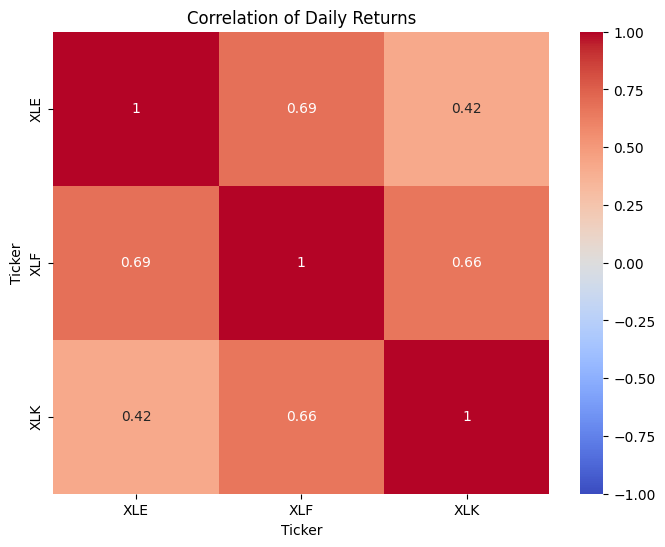

In [19]:
corr = returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation of Daily Returns')
plt.show()

In [20]:
## All three ETFs were positively correlated, though Energy showed lower correlation with Technology than the other pairings.

In [21]:
## Forecasting Model

## Exponential Smoothing was used to forecast XLK prices. The final 60 trading days were reserved as a test set.

In [22]:
xlk = prices['XLK']

train = xlk[:-60]
test = xlk[-60:]

model = ExponentialSmoothing(train, trend='add', seasonal=None)
fit = model.fit()

forecast = fit.forecast(60)

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


RMSE: 10.562943167956048
MAE: 9.425724708986762


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


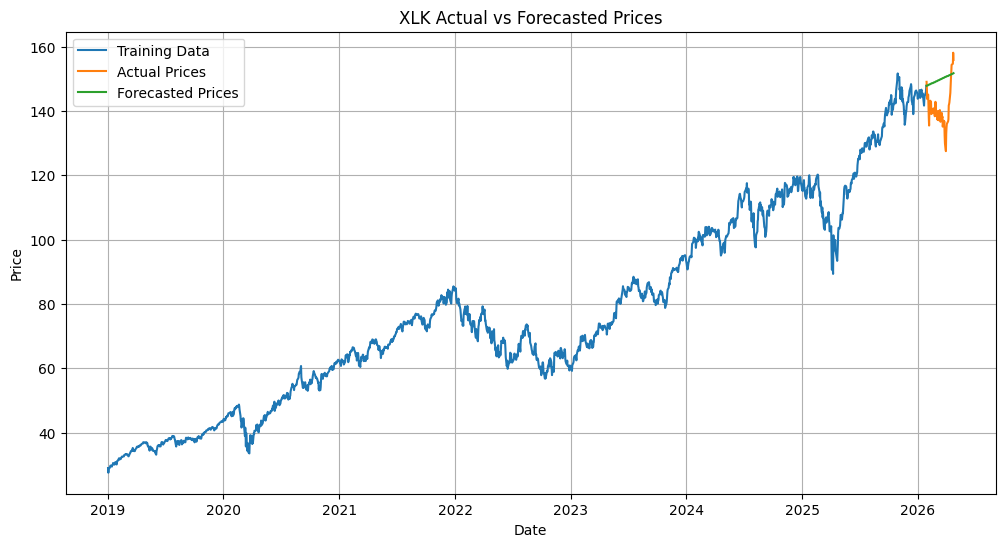

In [23]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Prices')
plt.plot(test.index, forecast, label='Forecasted Prices')

plt.title('XLK Actual vs Forecasted Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
## The model captured the general upward trend of XLK prices but was less accurate in predicting short-term market fluctuations.

In [25]:
## Conclusion

## This project demonstrated how time-series financial data can be cleaned, analyzed, and modeled using Python.
## XLK delivered the strongest long-term returns, XLE showed the highest volatility, and all three sectors displayed meaningful positive correlations.
## The forecasting model performed reasonably well in identifying trend direction, though daily market noise limited predictive precision.